In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

# Import the new refactored wrapper
from diffmap import diffmap

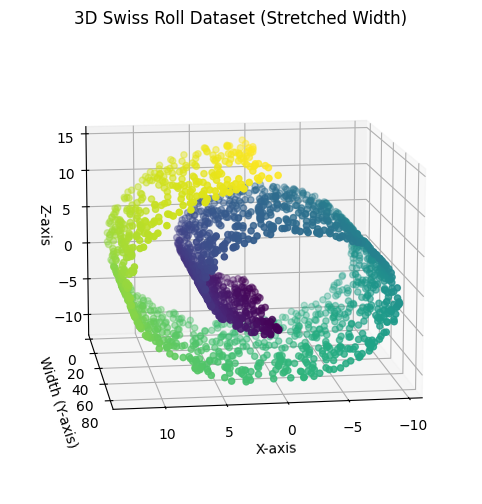

In [2]:
swissroll, color_var = make_swiss_roll(n_samples=2000, random_state=42)

# Stretch the width of the cylinder (Y-axis) so it becomes a primary harmonic
swissroll[:, 1] *= 4.0

# 1. Plot the Original 3D Swiss Roll
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Color points by their 1D unwrapped position (color_var)
ax.scatter(swissroll[:, 0], swissroll[:, 1], swissroll[:, 2], c=color_var, cmap=plt.cm.viridis)
ax.set_title("3D Swiss Roll Dataset (Stretched Width)")

# view angle
ax.view_init(elev=12, azim=82)

ax.set_xlabel("X-axis")
ax.set_ylabel("Width (Y-axis)")
ax.set_zlabel("Z-axis")
plt.show()

Running automatic spectral embedding...
Auto-selected epsilon (sparse BGH): 4.7619


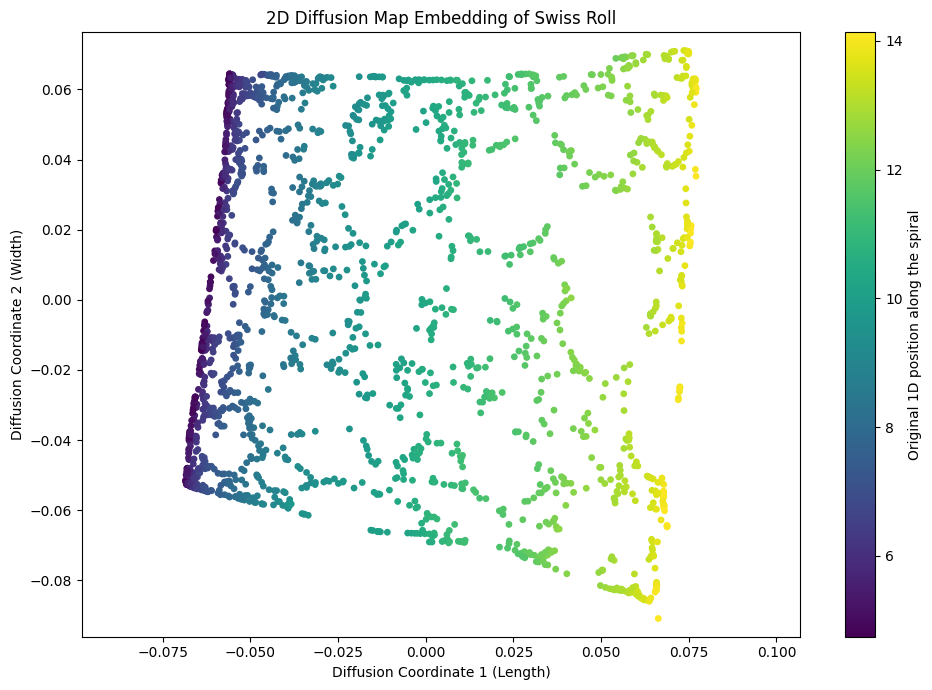

In [3]:
# 2. Run Diffusion Map on the dataset

print("Running automatic spectral embedding...")
embedding, eigval = diffmap(
    X=swissroll, 
    epsilon=None,     # Auto-calculate bandwidth
    method='auto',    # Automatically routes to sparse
    k=20,             # Keep k=20 for strong local connections
    alpha=1.0, 
    n_components=3, 
    t=1
)

# 3. Plot the 2D Mapped points with original colors
fig = plt.figure(figsize=(10, 7))

# Because we stretched the Y-axis above by 4.0, the first two eigenvectors 
# now naturally represent the "Length" and the "Width" of the unwrapped sheet!
plt.scatter(embedding[:, 0], embedding[:, 1], c=color_var, cmap=plt.cm.viridis, s=15)

plt.xlabel('Diffusion Coordinate 1 (Length)')
plt.ylabel('Diffusion Coordinate 2 (Width)')
plt.title('2D Diffusion Map Embedding of Swiss Roll')
plt.colorbar(label='Original 1D position along the spiral')
plt.axis('equal')

plt.tight_layout()
plt.show()

# Application: Human Activity Recognition (UCI HAR Dataset)

The UCI Human Activity Recognition (HAR) dataset contains data collected from 30 volunteers performing six basic activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) while wearing a smartphone (Samsung Galaxy S II) on their waist. The embedded accelerometer and gyroscope captured 3-axial linear acceleration and 3-axial angular velocity. 

**Goal:**
Our objective is to apply the Diffusion Map algorithm to this high-dimensional sensor data (561 features) to reduce its dimensionality to 2D or 3D. By doing so, we aim to uncover the underlying non-linear manifold of the data and visualize how well the distinct physical activities cluster together in the diffusion space.

In [4]:
import numpy as np
import os

# Load the UCI HAR dataset
base_dir = "../dataset/UCI HAR Dataset"

print("Loading UCI HAR dataset...")
# Load train set
X_train = np.loadtxt(os.path.join(base_dir, "train", "X_train.txt"))
y_train = np.loadtxt(os.path.join(base_dir, "train", "y_train.txt"), dtype=int)

# Load test set
X_test = np.loadtxt(os.path.join(base_dir, "test", "X_test.txt"))
y_test = np.loadtxt(os.path.join(base_dir, "test", "y_test.txt"), dtype=int)

# Load activity labels
with open(os.path.join(base_dir, "activity_labels.txt"), 'r') as f:
    activity_labels = [line.strip().split()[1] for line in f.readlines()]

print(f"Shape of training set: {X_train.shape}")
print(f"Shape of test set: {X_test.shape}")

Loading UCI HAR dataset...
Shape of training set: (7352, 561)
Shape of test set: (2947, 561)


Tabular preview of the raw 561-dimensional UCI HAR dataset:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity_ID,Activity_Name
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5,STANDING


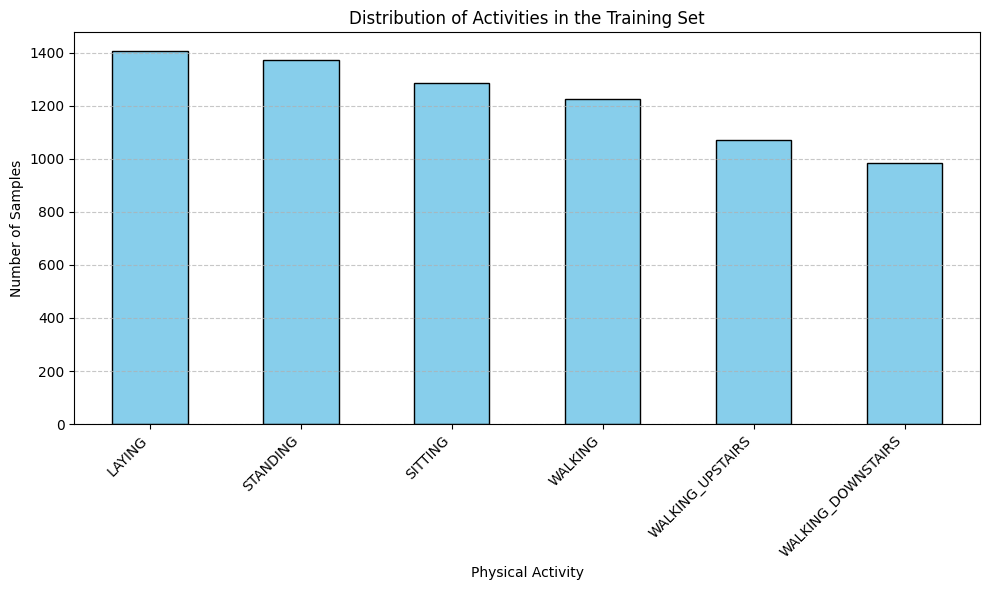

In [5]:
import pandas as pd
from IPython.display import display

# Load feature names to make the table descriptive
with open(os.path.join(base_dir, "features.txt"), 'r') as f:
    feature_names = [line.strip().split()[1] for line in f.readlines()]

# Create a full DataFrame with features and the target activity
df_train_full = pd.DataFrame(X_train, columns=feature_names)
df_train_full['Activity_ID'] = y_train
df_train_full['Activity_Name'] = df_train_full['Activity_ID'].map(lambda x: activity_labels[x-1])

print("Tabular preview of the raw 561-dimensional UCI HAR dataset:")
display(df_train_full.head())

# Let's visualize the distribution of activities in the training set
activity_counts = df_train_full['Activity_Name'].value_counts()

plt.figure(figsize=(10, 6))
activity_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Activities in the Training Set')
plt.xlabel('Physical Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Baseline: Random Forest on Raw Data (561 Dimensions)
Before applying Diffusion Map for dimensionality reduction, let's see how a standard Random Forest performs on the purely unreduced (561 features) dataset.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Training baseline Random Forest on the raw 561-dimensional training set...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# Extrapolate validation target classification outcomes 
y_pred_baseline = rf_baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)

print("="*60)
print("Baseline Classification Report (Raw 561 Dimensions -> RF)")
print("="*60)
print(classification_report(y_test, y_pred_baseline, target_names=activity_labels))
print(f"=> Baseline Test Set Accuracy: {baseline_acc*100:.2f}%")

Training baseline Random Forest on the raw 561-dimensional training set...
Baseline Classification Report (Raw 561 Dimensions -> RF)
                    precision    recall  f1-score   support

           WALKING       0.89      0.97      0.93       496
  WALKING_UPSTAIRS       0.90      0.89      0.89       471
WALKING_DOWNSTAIRS       0.97      0.87      0.91       420
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947

=> Baseline Test Set Accuracy: 92.57%


### Baseline 2: Random Forest on 10 Random Raw Features
To ensure the Diffusion Map is actually extracting meaningful topological signals, let's test what happens if we simply sample 10 random physical features from the raw dataset and train the same Random Forest classifier.

In [7]:
# Randomly select 10 feature indices out of the 561
np.random.seed(42)
random_10_indices = np.random.choice(X_train.shape[1], size=10, replace=False)

X_train_10 = X_train[:, random_10_indices]
X_test_10 = X_test[:, random_10_indices]

print("Training baseline Random Forest on 10 randomly selected unreduced features...")
rf_random10 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_random10.fit(X_train_10, y_train)

y_pred_random10 = rf_random10.predict(X_test_10)
random10_acc = accuracy_score(y_test, y_pred_random10)

print("="*60)
print("Baseline Classification Report (10 Random Features -> RF)")
print("="*60)
print(classification_report(y_test, y_pred_random10, target_names=activity_labels))
print(f"=> 10 Random Features Test Set Accuracy: {random10_acc*100:.2f}%")

Training baseline Random Forest on 10 randomly selected unreduced features...
Baseline Classification Report (10 Random Features -> RF)
                    precision    recall  f1-score   support

           WALKING       0.56      0.68      0.61       496
  WALKING_UPSTAIRS       0.80      0.68      0.74       471
WALKING_DOWNSTAIRS       0.61      0.56      0.59       420
           SITTING       0.50      0.47      0.49       491
          STANDING       0.53      0.56      0.54       532
            LAYING       0.69      0.69      0.69       537

          accuracy                           0.61      2947
         macro avg       0.62      0.61      0.61      2947
      weighted avg       0.61      0.61      0.61      2947

=> 10 Random Features Test Set Accuracy: 60.84%


### Dimensionality Reduction: Diffusion Map
Now, let's process the high-dimensional data using the Diffusion Map manifold learning to see if utilizing intrinsic topological features can achieve competitive accuracy with a fraction of the dimensionality.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from helpers import bgh, nystrom_extension
from diffmap import diffmap

# Bypass exhaustive cross-validation grid search to conserve computation.
# Best parameters identified for n_components=10 are k=15 and t=2.
param = {
    'k': 15,
    'n_components': 10,
    't': 2
}

In [9]:
# 1. Determine optimal kernel bandwidth (epsilon) using sparse BGH heuristic
final_epsilon = bgh(X_train, method='sparse', k=param['k'])

# 2. Extract non-linear eigenspace dimensions from the full training manifold
embedding_train, eigval_train = diffmap(
    X=X_train, 
    epsilon=final_epsilon,  
    method='sparse',  
    k=param['k'],             
    alpha=1.0, 
    n_components=param['n_components'],  
    t=param['t']
)

# 3. Project out-of-sample test instances via computationally efficient Nystrom approximation
embedding_test = nystrom_extension(X_test, X_train, embedding_train, eigval_train, final_epsilon, k=param['k'])

In [10]:
# 3. Train predictive Random Forest model strictly on the reduced continuous diffusion coordinates
clf_final = RandomForestClassifier(n_estimators=100, random_state=42)
clf_final.fit(embedding_train, y_train)

# Extrapolate validation target classification outcomes 
y_pred_final = clf_final.predict(embedding_test)

final_acc = accuracy_score(y_test, y_pred_final)

print("="*60)
print(f"Final Test classification using {param['n_components']} Diffusion Dimensions")
print("="*60)
print(classification_report(y_test, y_pred_final, target_names=activity_labels))
print(f"=> Random Forest Overall Test Set Accuracy: {final_acc*100:.2f}%")

Final Test classification using 10 Diffusion Dimensions
                    precision    recall  f1-score   support

           WALKING       0.83      0.92      0.87       496
  WALKING_UPSTAIRS       0.83      0.86      0.85       471
WALKING_DOWNSTAIRS       0.87      0.73      0.79       420
           SITTING       0.78      0.67      0.72       491
          STANDING       0.74      0.83      0.78       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.84      2947
         macro avg       0.84      0.84      0.84      2947
      weighted avg       0.84      0.84      0.84      2947

=> Random Forest Overall Test Set Accuracy: 84.02%


## Conclusion & Trade-offs
To evaluate the true effectiveness of the Diffusion Map, we compare its structural impact across extreme vs. mild dimension compression.

### The Strength: Extreme Compression (10 Dimensions)
1. **Full Dataset (561 dimensions):** Random Forest achieves **~92.57%**.
2. **Random Subsampling (10 purely random features):** Model crashes heavily to **~60.84%**.
3. **Diffusion Map (10 components):** Sustains a robust **~84%**.

When dimension reduction becomes uniquely aggressive (compressing the footprint by over **~98%**), standard random variable selection loses critical predictive geometry. Under these limits, the Diffusion Map effectively condenses high-dimensional sensor readings into minimal arrays, guarding against total diagnostic degradation.

### The Weakness: Diminishing Returns
If the dimension reduction target is still relatively large, the Diffusion Map becomes practically useless, as demonstrated below:

In [ ]:
# 1. 80 Random Raw Features Baseline
np.random.seed(42)
random_80_indices = np.random.choice(X_train.shape[1], size=80, replace=False)
X_train_80 = X_train[:, random_80_indices]
X_test_80 = X_test[:, random_80_indices]

rf_random80 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_random80.fit(X_train_80, y_train)
y_pred_random80 = rf_random80.predict(X_test_80)
random80_acc = accuracy_score(y_test, y_pred_random80)

# 2. Diffusion Map 80 Components 
emb_train_80, eigval_train_80 = diffmap(
    X=X_train, epsilon=final_epsilon, method='sparse', 
    k=15, alpha=1.0, n_components=80, t=1
)
# Project out-of-sample test
emb_test_80 = nystrom_extension(X_test, X_train, emb_train_80, eigval_train_80, final_epsilon, k=15)

# Train RF on 80 Diffusion components
clf_final_80 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_final_80.fit(emb_train_80, y_train)
y_pred_final_80 = clf_final_80.predict(emb_test_80)
final_80_acc = accuracy_score(y_test, y_pred_final_80)

print("="*60)
print("Demonstrating the Weakness: 80 Dimensions")
print("="*60)
print(f"=> 80 Random Raw Features Test Accuracy : {random80_acc*100:.2f}%")
print(f"=> 80 Diffusion Map Components Accuracy : {final_80_acc*100:.2f}%")
print(f"=> Full Dataset (561 Dimensions)        : {baseline_acc*100:.2f}%")

Demonstrating the Weakness: 80 Dimensions
=> 80 Random Raw Features Test Accuracy : 87.28%
=> 80 Diffusion Map Components Accuracy : 87.51%
=> Full Dataset (561 Dimensions)        : 92.57%


At 80 dimensions, calculating complex spectral embeddings barely edges out blindly choosing 80 random raw features, and it fails to replicate the native 92.57% of the total dataset. Given the heavy $O(N^3)$ (or large sparse $O(N^2)$) computational overhead required to generate a neighbor transition matrix and derive eigenvectors, utilizing a Diffusion Map for "mild" reductions is deeply inefficient and counter-productive.

**Key Takeaway:** 
The Diffusion Map is not a magical accuracy-boosting tool. It is exclusively an intrinsic manifold extractor. If a system can afford larger storage or vector boundaries, spectral dimensionality reduction adds computation for very little gain. Its true, objective value lies entirely in its ability to salvage geometric meaning when a model is artificially choked down to a tiny numeric bottleneck (e.g., 2D, 3D, or 10D limitations).

### Future Expansions & Advanced Topics

For readers or researchers interested in pushing Diffusion Maps further beyond this implementation, consider exploring the following advanced manifold learning concepts:

1. **Local Scaling (Self-Tuning Kernels):** Replaces a global bandwidth with a dynamic, point-specific radius ($\varepsilon_i$) to prevent dense clusters from over-smoothing while preserving connectivity in sparse regions (Zelnik-Manor & Perona, 2004).
   
2. **Mahalanobis Metric Learning:** Replaces the blind Euclidean distance calculation with a supervised Mahalanobis metric. By using training labels to mathematically stretch the space between overlapping classes (like "Sitting" and "Standing") before the random walk begins, the manifold cleanly separates them.

3. **Vector Diffusion Maps (VDM):** Upgrades standard scalar distances to orthogonal matrices that account for the rotational alignment of local tangent planes, solving distortion in highly curved or "twisted" physical manifolds.